# Organize results for downstream analyses
After denoising, hyperalignment, and isc are performed, you will need to prep the data for additional downstream analyses. In this notebook, you will prep the following:
1) Combine participant ISC results from the conversation task into a .cvs file for each condition. This fill will also have global conversation behavioral variables included to look at association with social connection outcomes. Run lme on della.\

2) Prep participant turn based information identifying the speak and listener blocks. Use this information to run the lag ISC script.

3) Combine participant lag-ISC results into a single .csv file for each condition and run lme analysis on della because it's just easier to work in R. 

In [ ]:
import os
import re
import h5py
import time

import numpy as np
import pandas as pd
from glob import glob
from natsort import natsorted
from os.path import join as opj


from nilearn import image, signal
from scipy.stats import zscore
from scipy.stats import pearsonr
from nltools.stats import fisher_r_to_z
from nilearn.datasets import fetch_atlas_schaefer_2018, fetch_atlas_harvard_oxford
from nltools.mask import expand_mask, roi_to_brain
from nltools.data import Brain_Data
from nltools.utils import concatenate
from natsort import natsorted
from brainiak.isc import isc
from scipy.signal import correlate, correlation_lags


## 1) Temporal Time-Locked ISC (whole-trial)
This segment of the code will combine participants individual ISC results that were outputed by running `~/code/slurm_hyp_isc.sh`. There are different sets of results depending on the model (model9 or model9_task) used, and the parcellation (Schaefer 100parcel 17network; Harvard-Oxford subcortical 21 parcel atlas; Glasser 360 parcel atlas) used in the analysis. Here, we include all of this information and combine the results into a single .csv file for each. 

**NOTE:** The code chunk below is aggregating ISC for each parcel based on data calculated across the whole-trial, meaning that I am NOT accounting for what might be accuring at the turn level!! The lagged-ISC calculates ISC at the turn-level, so use lag=0 results if you statistical analyses require turn-level specificity within a trial.



In [ ]:

# load behavioral data
beh_df = pd.read_csv("./CONV_behavior/CONV_Postscan_Global_clean.csv", header = [0])
data_dir = "./conversation_pipeline"
conditions = ["read","generate"]
models = ["model9", "model9_task"] #I ran model9|model9_task prior to 
atlas_labels = ["schaefer100p17n", "hosubcortical21p", "glasser360p"]

for condition in conditions:
    for atlas_label in atlas_labels:
        for model in models:    
            out_csv = opj(data_dir, "results", f"Temporal-ISC_{condition}_{model}_{atlas_label}_results.csv")
    
            # Grab  up any .h5 file containing 'ISC_Schaefer100p17n' (this will change by atlas)
            files = natsorted(glob(opj(data_dir, f"data/isc/*{condition}_ISC_{model}_{atlas_label}.h5")))
            print(f"Found {len(files)} files.")

            all_rows = []

            for file in files:
               filename = os.path.basename(file)
               parts = filename.split('_')
               dyad_id = parts[1]
               condition = parts[3]
               
               # Open HDF5, read dataset + attributes
               with h5py.File(file, 'r') as hf:
               isc_data = hf["isc"][...]  # shape => (n_parcels, n_trials)

               # Read attributes
               n_parcels = hf.attrs["n_parcels"]
               n_trials = hf.attrs["n_trials"]

               # Confirm shape is consistent with the attributes
               if isc_data.shape != (n_parcels, n_trials):
                 print(f"[WARNING] Mismatch in shape vs. attributes for {filename}!")
                 print(f"  isc_data.shape={isc_data.shape},  attributes=({n_parcels},{n_trials})")

             # Now build rows for each parcel x trial
               for parcel_idx in range(n_parcels):
                  for trial_idx in range(n_trials):
                     row = {
                        "dyad_id": dyad_id,
                        "condition": condition,
                        "group": beh_df.loc[beh_df['sub_id'] == opj(f"sub-0{dyad_id}"), 'Group'].values[0],
                        "trial": trial_idx + 1,
                        "parcel": parcel_idx + 1,
                        "isc": isc_data[parcel_idx, trial_idx],
                        "model" : model,
                        "atlas_name" : atlas_label
                     }
                     all_rows.append(row)

            # Convert all rows into a single DataFrame
            df = pd.DataFrame(all_rows)

            # Save to CSV
            df.to_csv(out_csv, index=False)
            print(f"[INFO] Saved combined ISC data to {out_csv} for {model} parcellation {atlas_label}")
            print(df.head(10))
            print(isc_data.shape)

### Wide format with behavioral measures
Here we create the output data with the trial level behavioral measures


In [ ]:
data_dir = "./conversation_pipeline"
beh_df = pd.read_csv("./CONV_behavior/CONV_Postscan_ItemLevel.csv", header = [0])

# 1) Normalize behavior table
beh_df.columns = [c.strip() for c in beh_df.columns]

# make dyad_num as two digits from "Dyad-##"
beh_df["dyad_num"] = beh_df["dyad_ids"].astype(str).str.extract(r"(\d+)")[0].astype(int).map(lambda x: f"{x:02d}")

# ensure trial key name matches your code
beh_df = beh_df.rename(columns={"trial_number": "trial"})
beh_df["partner"] = beh_df["partner"].astype(str)

# choose which behavioral columns to carry (here: everything except IDs you don’t want duplicated)
id_cols = {"dyad_ids", "dyad_num", "trial", "partner"}
beh_cols = [c for c in beh_df.columns if c not in id_cols]

# pivot wide so you get one row per dyad_num x trial, with columns like enjoyment_comp__0, enjoyment_comp__1, etc.
beh_wide = (
    beh_df.pivot_table(index=["dyad_num", "trial"], columns="partner", values=beh_cols, aggfunc="first")
          .sort_index(axis=1)
)
beh_wide.columns = [f"{col}__partner{partner}" for (col, partner) in beh_wide.columns]
beh_wide = beh_wide.reset_index()

conditions = ["read", "generate"]
models = ["model9_task", "model9"]
atlas_labels = ["schaefer100p17n", "hosubcortical21p", "glasser360p"]

for condition in conditions:
    for atlas_label in atlas_labels:
        for model in models:
            out_csv = opj(data_dir, "results", f"Temporal-ISC_behavior_{condition}_{model}_{atlas_label}_results.csv")

            files = natsorted(glob(opj(data_dir, f"data/isc/*{condition}_ISC_{model}_{atlas_label}.h5")))
            print(f"Found {len(files)} files.")

            all_df = []

            for file in files:
                filename = os.path.basename(file)
                parts = filename.split('_')

                 # your files look like dyad_03_cond_read_...
                dyad_num = parts[1]  # "03"
                cond_from_file = parts[3]

                with h5py.File(file, "r") as hf:
                    isc_data = hf["isc"][...]
                    n_parcels = int(hf.attrs["n_parcels"])
                    n_trials = int(hf.attrs["n_trials"])

                if isc_data.shape != (n_parcels, n_trials):
                    print(f"[WARNING] Shape mismatch for {filename}: {isc_data.shape} vs ({n_parcels},{n_trials})")

                # 2) Build ISC long dataframe (vectorized)
                df_isc = pd.DataFrame({
                    "dyad_num": dyad_num,
                     "condition": cond_from_file,
                    "trial": np.tile(np.arange(1, n_trials + 1), n_parcels),
                    "parcel": np.repeat(np.arange(1, n_parcels + 1), n_trials),
                    "isc": isc_data.reshape(-1),
                    "model": model,
                    "atlas_name": atlas_label
                })

                # 3) Merge behavior once (adds ALL behavioral columns)
                df_merged = df_isc.merge(beh_wide, on=["dyad_num", "trial"], how="left")

                all_df.append(df_merged)

            df = pd.concat(all_df, ignore_index=True)
            df.to_csv(out_csv, index=False)
            print(f"[INFO] Saved {out_csv}")
            print(df.head())

## 2) Lag-ISC (turn-based)
The code below will calculate lagged ISC for each model/atlas combination. 

### Temporal lag-ISC  
Here we move the listener relative to the speaker. ISC is calculated for the model specified across the 3 atlases specified in the analysis pipeline.  


In [ ]:
# functions
def get_dyad_bold(dyad_id, condition, out_paths):
    
    # Load dyad data
    dyad_data = []
    for out_path in out_paths:
        bold = load_bold_h5(out_path)
        dyad_data.append(bold)
    return dyad_data
            
def load_bold_h5(file_path, dataset_name="bold"):
    """
    Load data of shape (n_voxels, n_timepoints) from an H5 file.
    """
    print(file_path)
    with h5py.File(file_path, "r") as f:
        data = f[dataset_name][...]  # e.g., (n_voxels, n_timepoints)
    return data 

def xcorr(
    x: np.ndarray,
    y: np.ndarray,
    mode="full",
    method="fft",
    norm=True,
    maxlags=None,):
    
    """General function to compute cross correlation using scipy

    This function will center the data and normalize it by default.
    """

    # Center
    x = x - x.mean()
    y = y - y.mean()

    # Correlate
    corr = correlate(x, y, mode=mode, method=method)
    lags = correlation_lags(x.size, y.size, mode=mode)

    if norm:
        corr /= np.sqrt(np.dot(x, x) * np.dot(y, y))

    if maxlags is not None:
        middle = (lags == 0).nonzero()[0].item()
        lags = np.arange(-maxlags, maxlags + 1)
        corr = corr[middle - maxlags : middle + maxlags + 1]


    return corr, lags

# ---------------------- RUN

#Define parcels and parcel names
atlas_names = ['schaefer100p17n', 'glasser360p','hosubcortical21p']
models = ['model9_task', 'model9'] 

# Define directories 
data_dir = "./conversation_pipeline/data"
hyp_dir = opj(data_dir, "hyperaligned/srm_task-Conv")
lag_dir = opj(data_dir,"lag-isc")

# Define lag ISC parameters
min_turn_length = 14
max_lag = 4
conditions = ["generate", "read"]

# Load behavior 
beh_df = pd.read_csv("./CONV_behavior/CONV_Postscan_Global_clean.csv", header = [0])
# Filter out excluded subjects
exclude_list = ['sub-001','sub-101','sub-011','sub-111','sub-012','sub-112',
                    'sub-019','sub-119','sub-068','sub-168','sub-071','sub-171']
beh_df = beh_df[~beh_df['sub_id'].isin(exclude_list)]
beh_df['dyad_id'] = [row[-2:] for row in beh_df['sub_id']]

# --------------------------------- RUN LAGGED-ISC ---------------------------------------------------------------
for cond in conditions:

    for atlas_name in atlas_names:
        print(f"[INFO]: Starting lag-ISC for {atlas_name}-{cond}.")

        if atlas_name == "schaefer100p17n":
            atlas_file = fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17)
            atlas_img = Brain_Data(atlas_file['maps'])
            parcels = np.r_[0:100]
            labels =  atlas_file['labels']
            parcel_names = [label.decode('utf-8') if isinstance(label, bytes) else label for label in labels]

        if atlas_name == "hosubcortical21p":
            atlas_file = fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
            atlas_img = Brain_Data(atlas_file['maps'])
            parcels = np.r_[0:21] 
            labels =  atlas_file['labels']
            parcel_names = [label.decode('utf-8') if isinstance(label, bytes) else label for label in labels]

        if atlas_name == "glasser360p":
            atlas_img = Brain_Data('./conversation_pipeline/data/atlases/glasser360MNI.nii')
            parcels = np.r_[0:359] 
            labels = pd.read_csv('./conversation_pipeline/data/atlases/glasser360NodeNames.txt', header = None, delimiter='\t')
            parcel_names = labels 
        
        atlas_x_mask= expand_mask(atlas_img)

        
        for dyad_id in beh_df.dyad_id.unique():
            print(dyad_id)
            trial_results = []
            group = beh_df.Group[beh_df['dyad_id'] == dyad_id].unique()[0]

            for model in models:
                # Load bold data for both members of the dyad
                out_paths = natsorted(glob(opj(hyp_dir, f"sub-*{dyad_id}_cond_{cond}_{model}_{atlas_name}.h5")))
                dyad_data = np.stack(get_dyad_bold(dyad_id, cond, out_paths))  # shape: (2, n_parcels, n_TRs)

                # Load trial-level role info
                role_file = glob(opj(lag_dir, f"trial_roles/{cond}/dyad_1{dyad_id}_{cond}-speaking_listening.csv"))[0]
                role_df = pd.read_csv(role_file, header=0)

                for i in range(10):  # loop through 10 trials
                    role_df_trial = role_df[role_df['trial'] == i + 1]
                    print(f"[INFO]: Dyad-{dyad_id} Trial-{i+1}: Total turns = {len(role_df_trial)}")

                    for t, turn in enumerate(role_df_trial.index):
                        role = role_df_trial.loc[turn, 'role']
                        startTR = role_df_trial.loc[turn, 'startTR']
                        endTR = role_df_trial.loc[turn, 'endTR']
                        duration = endTR - startTR

                        if duration < min_turn_length:
                            print(f"[SKIP]: Turn too short ({duration} TRs)")
                        continue
                        
                        # Remember the roles csv data are based on sub-1**!!!
                        if role == 'listening':
                            speaker_ts = dyad_data[0]  # sub-1** listening
                            listener_ts = dyad_data[1]
                            speaker = f"sub-0{dyad_id}"
                        elif role == 'speaking':
                            speaker_ts = dyad_data[1]  # sub-1** speaking
                            listener_ts = dyad_data[0]
                            speaker = f"sub-1{dyad_id}"
                        else:
                            print(f"[SKIP]: Role not recognized")
                            continue

                        # Pad TRs for lag shifting
                        padded_start = max(0, startTR - max_lag)
                        padded_end = min(dyad_data.shape[2], endTR + max_lag)

                        for p, parcel in enumerate(parcels):
                            # the label format for glasser is a little different since it's from .txt file so need to account for that!
                            if atlas_name == "glasser360p":
                                p_label = labels[0][p]
                            if atlas_name == "hosubcortical21p":
                             p_label = labels[p+1]
                            if atlas_name == "schaefer100p17n":
                                p_label = parcel_names[p]
                            s = speaker_ts[parcel, padded_start:padded_end]
                            l = listener_ts[parcel, padded_start:padded_end]

                            # Compute lagged xcorr
                            corr_vals, lags = xcorr(x=l, y=s, norm=True, maxlags=max_lag)

                            for lag_val, corr in zip(lags, corr_vals):
                                trial_results.append({
                                    'dyad_id': f'Dyad-{dyad_id}',
                                    'group': group,
                                    'condition': cond,
                                    'trial': i + 1,
                                    'turn': t,
                                    'run': role_df_trial.run.unique()[0],
                                    'duration': duration,
                                    'lag': lag_val,
                                    'parcel': parcel,
                                    'parcel_label': p_label,
                                    'temporal_ISC': corr,
                                    'model' : model,
                                    'atlas_name' : atlas_name
                                })

                results_df = pd.DataFrame(trial_results)
                results_df["temporal_ISC_z"] = results_df["temporal_ISC"].apply(
                    lambda r: np.arctanh(r) if np.abs(r) < 1 else np.nan
                )

                output_file = opj(
                    lag_dir, cond,
                    f"dyad_{dyad_id}_cond_{cond}_ISC-lag-temp_{model}_{atlas_name}_thr{min_turn_length}TRs_listener-shifting.csv"
                )
                results_df.to_csv(output_file, index=False)
                print(f"[SAVED]: {output_file}")


<!-- To copy these files to della do: rsync -r ./conversation_pipeline/data/lag-isc/LagISC_*model9_schaefer100p17n*.csv lm1074@della.princeton.edu:/scratch/gpfs/TAMIR/lm1074/temporal_spatial_isc/data -->


## 3) Anatomical ISC: Combine ISC results
For supplementary. Send to slurm `slurm_anat_isc.sh`

## 4) Autocorrelation test
Is autocorrelation contributing to the lagged results peaks being between -1 and +1 where the HRF might also be convolved with this?

In [ ]:
# from joblib import Parallel, delayed

# def extract_turn_segments_for_dyad(
#     dyad_id,
#     cond,
#     atlas_name,
#     labels,
#     parcel_names,
#     parcels,
#     hyp_dir,
#     lag_dir,
#     model,
#     beh_df,
#     min_turn_length=14,
#     max_lag=4
# ):
#     turn_segments = []

#     print(f"[DEBUG] extract_turn_segments_for_dyad: dyad={dyad_id}, cond={cond}")

#     # group
#     group_vals = beh_df.loc[beh_df["dyad_id"] == dyad_id, "Group"].unique()
#     if len(group_vals) == 0:
#         print(f"[ERROR] No group found for dyad={dyad_id}")
#         return pd.DataFrame()
#     group = group_vals[0]

#     # bold files
#     out_paths = natsorted(
#         glob(opj(hyp_dir, f"sub-*{dyad_id}_cond_{cond}_{model}_{atlas_name}.h5"))
#     )
#     print(f"[DEBUG] out_paths for dyad={dyad_id}: {out_paths}")

#     if len(out_paths) != 2:
#         print(f"[ERROR] Expected 2 BOLD files, found {len(out_paths)} for dyad={dyad_id}, cond={cond}")
#         return pd.DataFrame()

#     dyad_data = get_dyad_bold(out_paths)

#     # role file
#     role_files = glob(
#         opj(lag_dir, f"trial_roles/{cond}/dyad_1{dyad_id}_{cond}-speaking_listening.csv")
#     )
#     print(f"[DEBUG] role_files for dyad={dyad_id}: {role_files}")

#     if len(role_files) == 0:
#         print(f"[ERROR] No role file found for dyad={dyad_id}, cond={cond}")
#         return pd.DataFrame()

#     role_file = role_files[0]
#     role_df = pd.read_csv(role_file, header=0)

#     for i in range(10):
#         role_df_trial = role_df[role_df["trial"] == i + 1]
#         print(f"[INFO] Dyad-{dyad_id} Trial-{i+1}: Total turns = {len(role_df_trial)}")

#         if len(role_df_trial) == 0:
#             continue

#         run_vals = role_df_trial["run"].unique()
#         if len(run_vals) == 0:
#             print(f"[WARN] No run value for Dyad-{dyad_id}, Trial-{i+1}")
#             continue
#         run_val = run_vals[0]

#         for t, turn in enumerate(role_df_trial.index):
#             role = role_df_trial.loc[turn, "role"]
#             startTR = int(role_df_trial.loc[turn, "startTR"])
#             endTR = int(role_df_trial.loc[turn, "endTR"])
#             duration = int(endTR - startTR)

#             if duration < min_turn_length:
#                 continue

#             if role == "listening":
#                 speaker_ts_all = dyad_data[0]
#                 listener_ts_all = dyad_data[1]
#                 speaker = f"sub-0{dyad_id}"
#             elif role == "speaking":
#                 speaker_ts_all = dyad_data[1]
#                 listener_ts_all = dyad_data[0]
#                 speaker = f"sub-1{dyad_id}"
#             else:
#                 continue

#             padded_start = max(0, startTR - max_lag)
#             padded_end = min(dyad_data.shape[2], endTR + max_lag)

#             for p, parcel in enumerate(parcels):
#                 if atlas_name == "glasser360p":
#                     p_label = labels.iloc[p, 0]
#                 elif atlas_name == "hosubcortical21p":
#                     p_label = labels[p + 1]
#                 elif atlas_name == "schaefer100p17n":
#                     p_label = parcel_names[p]
#                 else:
#                     p_label = str(parcel)

#                 s = speaker_ts_all[parcel, padded_start:padded_end].copy()
#                 l = listener_ts_all[parcel, padded_start:padded_end].copy()

#                 turn_segments.append({
#                     "dyad_id": f"Dyad-{dyad_id}",
#                     "group": group,
#                     "condition": cond,
#                     "trial": i + 1,
#                     "turn": t,
#                     "run": run_val,
#                     "duration": duration,
#                     "speaker": speaker,
#                     "parcel": int(parcel),
#                     "parcel_label": p_label,
#                     "speaker_ts": s,
#                     "listener_ts": l
#                 })

#     return pd.DataFrame(turn_segments)

# def process_one_dyad(dyad_id, cond, atlas_name, labels, parcel_names, parcels,
#                      hyp_dir, lag_dir, model, beh_df,
#                      min_turn_length=14, max_lag=4, n_perm=20):

#     print(f"[INFO] Processing Dyad-{dyad_id}, {cond}")

#     try:
#         print(f"[INFO] Processing Dyad-{dyad_id}, {cond}")

#         turn_segments_df = extract_turn_segments_for_dyad(
#             dyad_id=dyad_id,
#             cond=cond,
#             atlas_name=atlas_name,
#             labels=labels,
#             parcel_names=parcel_names,
#             parcels=parcels,
#             hyp_dir=hyp_dir,
#             lag_dir=lag_dir,
#             model=model,
#             beh_df=beh_df,
#             min_turn_length=min_turn_length,
#             max_lag=max_lag
#         )

#         if turn_segments_df is None or turn_segments_df.empty:
#             print(f"[WARN] No valid turn segments for Dyad-{dyad_id}, {cond}")
#             return None

#         observed_df = compute_observed_lagged_isc(turn_segments_df, max_lag=max_lag)
#         observed_peak_df = compute_peak_df(observed_df)

#         observed_stats, null_stats = run_permutation_test(
#             turn_segments_df=turn_segments_df,
#             observed_peak_df=observed_peak_df,
#             n_perm=n_perm,
#             max_lag=max_lag,
#             use_duration_bins=True
#         )

#         pvals_df = permutation_pvalues(
#             observed_stats=observed_stats,
#             null_stats=null_stats,
#             stat_cols=["prop_peak_0", "mean_peak_isc", "mean_abs_peak"]
#         )

#         return {
#             "observed_df": observed_df,
#             "observed_peak_df": observed_peak_df,
#             "observed_stats": observed_stats,
#             "null_stats": null_stats,
#             "pvals_df": pvals_df
#         }

#     except Exception as e:
#         print(f"[ERROR] Dyad-{dyad_id}, cond={cond}: {e}")
#         return None
# # ----------------------
# # PARAMETERS 
# # ----------------------
# atlas_names = ["schaefer100p17n"], ["glasser360p"] ["hosubcortical21p"]
# model = "model9_task"

# data_dir = os.path.expanduser("./conversation_pipeline/data")
# hyp_dir = opj(data_dir, "hyperaligned/srm_task-Conv")
# lag_dir = opj(data_dir, "lag-isc")

# min_turn_length = 14
# max_lag = 4
# conditions = ["generate"] #, "read"]

# # ----------------------
# # Load behavior
# # ----------------------
# beh_df = pd.read_csv(os.path.expanduser("./CONV_behavior/CONV_Postscan_Global_clean.csv"), header=0)

# exclude_list = [
#         "sub-001", "sub-101", "sub-011", "sub-111", "sub-012", "sub-112",
#         "sub-019", "sub-119", "sub-068", "sub-168", "sub-071", "sub-171"]
# beh_df = beh_df[~beh_df["sub_id"].isin(exclude_list)].copy()
# beh_df["dyad_id"] = [row[-2:] for row in beh_df["sub_id"]]
# n_perm = 500

# for cond in conditions:
#      for atlas_name in atlas_names:
#         print(f"[INFO] Starting analysis for atlas={atlas_name}, condition={cond}")
#         dyad_ids = beh_df.dyad_id.unique() 
        
#         if atlas_name == "schaefer100p17n":
#             atlas_file = fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17)
#             atlas_img = Brain_Data(atlas_file["maps"])
#             parcels = np.r_[0:100]
#             labels = atlas_file["labels"]
#             parcel_names = [label.decode("utf-8") if isinstance(label, bytes) else label for label in labels]

#         elif atlas_name == "hosubcortical21p":
#             atlas_file = fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
#             atlas_img = Brain_Data(atlas_file["maps"])
#             parcels = np.r_[0:21]
#             labels = atlas_file["labels"]
#             parcel_names = [label.decode("utf-8") if isinstance(label, bytes) else label for label in labels]

#         elif atlas_name == "glasser360p":
#             atlas_img = Brain_Data(os.path.expanduser("./conversation_pipeline/data/atlases/glasser360MNI.nii"))
#             parcels = np.r_[0:359]
#             labels = pd.read_csv(
#                 os.path.expanduser("./conversation_pipeline/data/atlases/glasser360NodeNames.txt"),
#                 header=None,
#                 delimiter="\t"
#             )
#             parcel_names = labels[0].tolist()

#         else:
#             raise ValueError(f"Unknown atlas_name: {atlas_name}")

#         atlas_x_mask = expand_mask(atlas_img)
        
#         results = Parallel(n_jobs=20, verbose=10)(
#             delayed(process_one_dyad)(
#                 dyad_id,
#                 cond,
#                 atlas_name,
#                 labels,
#                 parcel_names,
#                 parcels,
#                 hyp_dir,
#                 lag_dir,
#                 model,
#                 beh_df,
#                 min_turn_length,
#                 max_lag,
#                 n_perm
#              )
#             for dyad_id in dyad_ids
#         )

### AR(1) whitening data

#### Test AR(1) modeling works

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# import matplotlib.pyplot as plt

# # def prewhiten_ar1(timeseries):
# #     """
# #     Fits an AR(1) model to a timeseries and returns the residuals (prewhitened series).

# #     Args:
# #         timeseries (pd.Series or np.array): The input time series data.

# #     Returns:
# #         pd.Series: The residuals (white noise series) from the fitted AR(1) model.
# #     """
# #     # Ensure the input is a pandas Series for easier handling, if not already
# #     # if not isinstance(timeseries, pd.Series):
# #     #     timeseries = pd.Series(timeseries)
        
# #     # Fit the AR(1) model (order=(1, 0, 0) for AR(1), I(0), MA(0))
# #     # 'css-mle' method is a robust choice for fitting
# #     model = ARIMA(timeseries, order=(1, 0, 0))
# #     results = model.fit()
    
# #     # The residuals are the prewhitened series
# #     residuals = results.resid
# def load_bold_h5(file_path, dataset_name="bold"):
#     """
#     Load data of shape (n_voxels, n_timepoints) from an H5 file.
#     """
#     print(file_path)
#     with h5py.File(file_path, "r") as f:
#         data = f[dataset_name][...]  # e.g., (n_voxels, n_timepoints)
#     return data 
  
# def prewhiten_ar1(ts):
#     ts = np.asarray(ts, dtype=float)

#     if len(ts) < 2:
#         return np.full_like(ts, np.nan)

#     x_prev = ts[:-1]
#     x_curr = ts[1:]

#     denom = np.dot(x_prev, x_prev)
#     if denom == 0:
#         return np.full_like(ts, np.nan)

#     phi = np.dot(x_prev, x_curr) / denom

#     resid = np.empty_like(ts)
#     resid[0] = np.nan
#     resid[1:] = x_curr - phi * x_prev

#     return resid

# def get_dyad_bold(dyad_id, condition, out_paths):
    
#     # Load dyad data
#     dyad_data = []
#     for out_path in out_paths:
#         bold = load_bold_h5(out_path)
#         dyad_data.append(bold)
#     return dyad_data


# #Define parcels and parcel names
# atlas_name = 'glasser360p' #atlas_names = ['schaefer100p17n', 'glasser360p','hosubcortical21p']
# model = 'model9_task' #models = ['model9_task', 'model9']

# # Define directories 
# data_dir = "./conversation_pipeline/data"
# hyp_dir = opj(data_dir, "hyperaligned/srm_task-Conv")
# lag_dir = opj(data_dir,"lag-isc")

# # Load behavior 
# beh_df = pd.read_csv("./CONV_behavior/CONV_Postscan_Global_clean.csv", header = [0])
# # Filter out excluded subjects
# exclude_list = ['sub-001','sub-101','sub-011','sub-111','sub-012','sub-112',
#                     'sub-019','sub-119','sub-068','sub-168','sub-071','sub-171']
# beh_df = beh_df[~beh_df['sub_id'].isin(exclude_list)]
# beh_df['dyad_id'] = [row[-2:] for row in beh_df['sub_id']]

# dyad_id = beh_df.dyad_id.unique()[0]
# print(beh_df['sub_id'][0])
# cond = "generate"  # or "read"
# out_paths = natsorted(glob(opj(hyp_dir, f"sub-*{dyad_id}_*{cond}_{atlas_name}.h5")))
# dyad_data = np.stack(get_dyad_bold(dyad_id, cond, out_paths))  # shape: (2, parcels, TRs)

# # pick one parcel and one subject
# parcel_idx = 23 #9 
# ts_raw = dyad_data[0, parcel_idx, 7:120]  # first 200 TRs for visualization

# # y_series = pd.Series(ts_raw)
# ts_white = prewhiten_ar1(ts_raw)

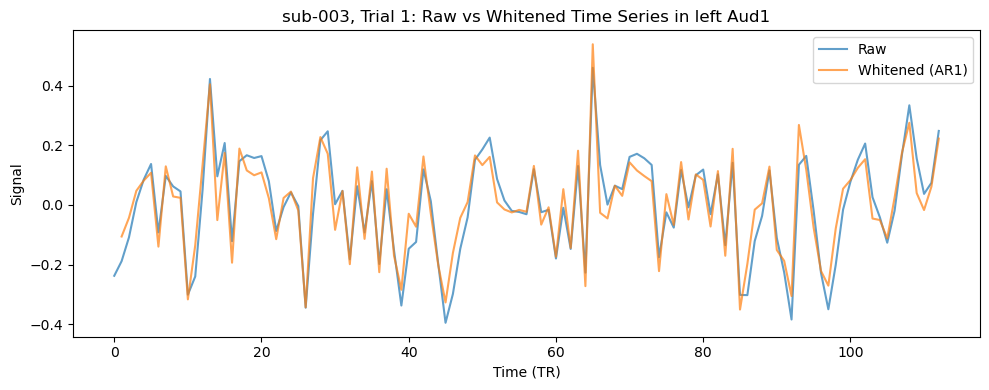

In [ ]:
# plt.figure(figsize=(10,4))

# plt.plot(ts_raw, label="Raw", alpha=0.7)
# plt.plot(ts_white, label="Whitened (AR1)", alpha=0.7)

# plt.title(f"{beh_df['sub_id'][0]}, Trial 1: Raw vs Whitened Time Series in left Aud1")
# plt.xlabel("Time (TR)")
# plt.ylabel("Signal")
# plt.legend()

# plt.tight_layout()
# plt.show()

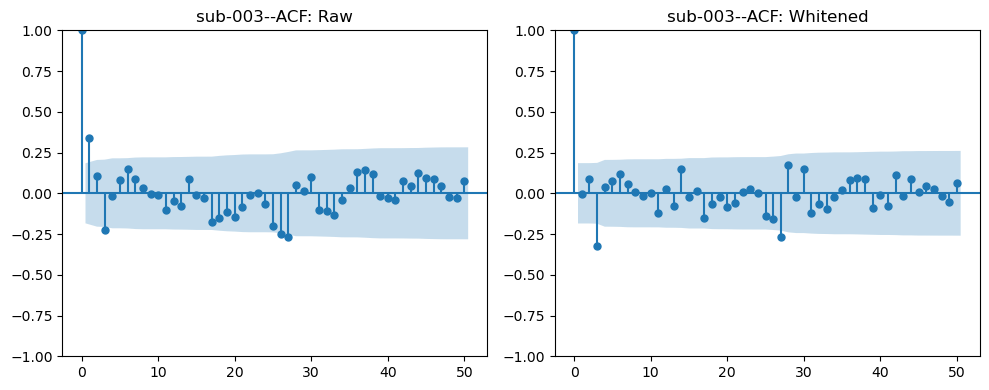

In [ ]:
# from statsmodels.graphics.tsaplots import plot_acf

# fig, axes = plt.subplots(1, 2, figsize=(10,4))

# plot_acf(ts_raw, lags=50, ax=axes[0])
# axes[0].set_title(f"{beh_df['sub_id'][0]}--ACF: Raw")

# plot_acf(ts_white[~np.isnan(ts_white)], lags=50, ax=axes[1])
# axes[1].set_title(f"{beh_df['sub_id'][0]}--ACF: Whitened")

# plt.tight_layout()
# plt.show()

#### Run on full dataset
 Prewhitening the data with AR(1) and re-run lagged analysis.

In [ ]:

# Setup functions

def get_dyad_bold(dyad_id, condition, out_paths):
    
    # Load dyad data
    dyad_data = []
    for out_path in out_paths:
        bold = load_bold_h5(out_path)
        dyad_data.append(bold)
    return dyad_data
            
def load_bold_h5(file_path, dataset_name="bold"):
    """
    Load data of shape (n_voxels, n_timepoints) from an H5 file.
    """
    print(file_path)
    with h5py.File(file_path, "r") as f:
        data = f[dataset_name][...]  # e.g., (n_voxels, n_timepoints)
    return data 


def xcorr(
    x: np.ndarray,
    y: np.ndarray,
    mode="full",
    method="fft",
    norm=True,
    maxlags=None,):
    
    """General function to compute cross correlation using scipy
    """

    # Center
    x = x - x.mean()
    y = y - y.mean()

    # Correlate
    corr = correlate(x, y, mode=mode, method=method)
    lags = correlation_lags(x.size, y.size, mode=mode)

    if norm:
        corr /= np.sqrt(np.dot(x, x) * np.dot(y, y))

    if maxlags is not None:
        middle = (lags == 0).nonzero()[0].item()
        lags = np.arange(-maxlags, maxlags + 1)
        corr = corr[middle - maxlags : middle + maxlags + 1]


    return corr, lags
# ---------------------- RUN

#Define parcels and parcel names
atlas_names = ['schaefer100p17n'] #'schaefer100p17n', 'glasser360p','hosubcortical21p'
model = 'model9_task'

# Define directories 
data_dir = "./conversation_pipeline/data"
hyp_dir = opj(data_dir, "hyperaligned/srm_task-Conv")
lag_dir = opj(data_dir,"lag-isc")

# Define lag ISC parameters
min_turn_length = 14
max_lag = 4
conditions = ["generate", "read"]

# Load behavior 
beh_df = pd.read_csv("./CONV_behavior/CONV_Postscan_Global_clean.csv", header = [0])
# Filter out excluded subjects
exclude_list = ['sub-001','sub-101','sub-011','sub-111','sub-012','sub-112',
                    'sub-019','sub-119','sub-068','sub-168','sub-071','sub-171']
beh_df = beh_df[~beh_df['sub_id'].isin(exclude_list)]
beh_df['dyad_id'] = [row[-2:] for row in beh_df['sub_id']]

# --------------------------------- RUN LAGGED-ISC ---------------------------------------------------------------
for cond in conditions:

    for atlas_name in atlas_names:
        print(f"[INFO]: Starting lag-ISC for {atlas_name}-{cond}.")

        if atlas_name == "schaefer100p17n":
            atlas_file = fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17)
            atlas_img = Brain_Data(atlas_file['maps'])
            parcels = np.r_[0:100]
            labels =  atlas_file['labels']
            parcel_names = [label.decode('utf-8') if isinstance(label, bytes) else label for label in labels]

        if atlas_name == "hosubcortical21p":
            atlas_file = fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
            atlas_img = Brain_Data(atlas_file['maps'])
            parcels = np.r_[0:21] 
            labels =  atlas_file['labels']
            parcel_names = [label.decode('utf-8') if isinstance(label, bytes) else label for label in labels]

        if atlas_name == "glasser360p":
            atlas_img = Brain_Data('./conversation_pipeline/data/atlases/glasser360MNI.nii')
            parcels = np.r_[0:359] 
            labels = pd.read_csv('./conversation_pipeline/data/atlases/glasser360NodeNames.txt', header = None, delimiter='\t')
            parcel_names = labels 
        
        atlas_x_mask= expand_mask(atlas_img)

        
        for dyad_id in beh_df.dyad_id.unique():
            print(dyad_id)
            trial_results = []
            group = beh_df.Group[beh_df['dyad_id'] == dyad_id].unique()[0]

            # Load bold data for both members of the dyad
            if atlas_name == 'glasser360p':
                out_paths = natsorted(glob(opj(hyp_dir, f"sub-*{dyad_id}_cond_{cond}_{atlas_name}.h5")))
            else:
                out_paths = natsorted(glob(opj(hyp_dir, f"sub-*{dyad_id}_cond_{cond}_{model}_{atlas_name}.h5")))
            dyad_data = np.stack(get_dyad_bold(dyad_id, cond, out_paths))  # shape: (2, n_parcels, n_TRs)

            # Load trial-level role info
            role_file = glob(opj(lag_dir, f"trial_roles/{cond}/dyad_1{dyad_id}_{cond}-speaking_listening.csv"))[0]
            role_df = pd.read_csv(role_file, header=0)

            for i in range(10):  # loop through 10 trials
                role_df_trial = role_df[role_df['trial'] == i + 1]
                print(f"[INFO]: Dyad-{dyad_id} Trial-{i+1}: Total turns = {len(role_df_trial)}")

                for t, turn in enumerate(role_df_trial.index):
                    role = role_df_trial.loc[turn, 'role']
                    startTR = role_df_trial.loc[turn, 'startTR']
                    endTR = role_df_trial.loc[turn, 'endTR']
                    duration = endTR - startTR

                    if duration < min_turn_length:
                        print(f"[SKIP]: Turn too short ({duration} TRs)")
                        continue
                    
                    # Remember the roles csv data are based on sub-1**!!!
                    if role == 'listening':
                        speaker_ts = dyad_data[0]  # sub-1** listening
                        listener_ts = dyad_data[1]
                        speaker = f"sub-0{dyad_id}"
                    elif role == 'speaking':
                        speaker_ts = dyad_data[1]  # sub-1** speaking
                        listener_ts = dyad_data[0]
                        speaker = f"sub-1{dyad_id}"
                    else:
                        print(f"[SKIP]: Role not recognized")
                        continue

                    # Pad TRs for lag shifting
                    padded_start = max(0, startTR - max_lag)
                    padded_end = min(dyad_data.shape[2], endTR + max_lag)

                    for p, parcel in enumerate(parcels):
                        # the label format for glasser is a little different since it's from .txt file so need to account for that!
                        if atlas_name == "glasser360p":
                            p_label = labels[0][p]
                        if atlas_name == "hosubcortical21p":
                            p_label = labels[p+1]
                        if atlas_name == "schaefer100p17n":
                            p_label = parcel_names[p]

                        #padding then prewhitening
                        s = speaker_ts[parcel, padded_start:padded_end].copy()
                        l = listener_ts[parcel, padded_start:padded_end].copy()

                        s_w = prewhiten_ar1(s)
                        l_w = prewhiten_ar1(l)

                        valid = np.isfinite(s_w) & np.isfinite(l_w)
                        s_w = s_w[valid]
                        l_w = l_w[valid]

                        if len(s_w) < (2 * max_lag + 3):
                            continue

                        # Compute lagged xcorr
                        corr_vals, lags = xcorr(x=l_w, y=s_w, norm=True, maxlags=max_lag)

                        for lag_val, corr in zip(lags, corr_vals):
                            trial_results.append({
                                'dyad_id': f'Dyad-{dyad_id}',
                                'group': group,
                                'condition': cond,
                                'trial': i + 1,
                                'turn': t,
                                'run': role_df_trial.run.unique()[0],
                                'duration': duration,
                                'lag': lag_val,
                                'parcel': parcel,
                                'parcel_label': p_label,
                                'temporal_ISC': corr,
                                'model' : model,
                                'atlas_name' : atlas_name
                            })

            results_df = pd.DataFrame(trial_results)
            results_df["temporal_ISC_z"] = results_df["temporal_ISC"].apply(
                lambda r: np.arctanh(r) if np.abs(r) < 1 else np.nan
            )

            output_file = opj(
                lag_dir, cond,
                f"dyad_{dyad_id}_cond_{cond}_ISC-lag-temp_{model}_{atlas_name}_thr{min_turn_length}TRs_listener-shifting_AR1.csv"
            )
            results_df.to_csv(output_file, index=False)
            print(f"[SAVED]: {output_file}")

In [ ]:
conditions = ["generate", "read"]
atlas_name = 'schaefer100p17n'
model = 'model9_task'


for cond in conditions:
    print(cond)
    all_files = natsorted(glob(opj(lag_dir,cond,f"dyad*_cond_{cond}_ISC-lag-temp_{model}_{atlas_name}*listener-shifting_AR1.csv")))
    
    # Create an empty list to store DataFrames
    all_df = []

    # Iterate over the list of files
    for f in all_files:
        # Read each CSV file into a dataframe
        df = pd.read_csv(f)
        all_df.append(df)

    # save condition file
    merged_df = pd.concat(all_df, ignore_index=True)
    outpath = opj(lag_dir,f"LagISC_{cond}_{model}_{atlas_name}_alldyads_thr14TRS_listener-shifting_AR1.csv")
    merged_df.to_csv(outpath, index = False)

generate
read
